### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [2]:
tf.__version__

'1.14.0'

### Collect Data

In [3]:
import keras

Using TensorFlow backend.


In [4]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

4423680/4422102 [==============================] - 1s 0us/step


In [5]:
print(testY[0:5])

[9 2 1 1 6]


In [6]:
print(trainY[0:5])

[9 0 0 3 0]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

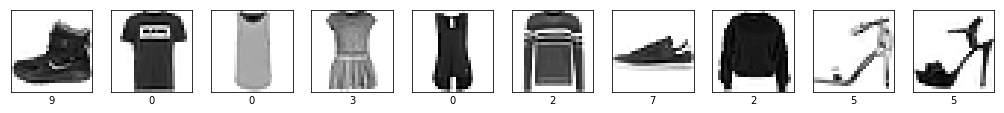

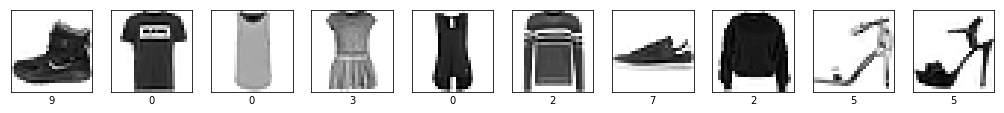

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline 
fig = plt.figure(figsize=(50,50))
for i in range(10):
  plt.subplot(28,28,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(trainX[i], cmap=plt.cm.binary)
  plt.xlabel(trainY[i])
fig

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [0]:
trainY= tf.keras.utils.to_categorical(trainY)
testY= tf.keras.utils.to_categorical(testY)

In [9]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [0]:
x_train=trainX.reshape(trainX.shape[0],28,28,1).astype('float32')
x_test=testX.reshape(testX.shape[0],28,28,1).astype('float32')

In [0]:
x_train/=255
x_test/=255

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [0]:
from keras.models import Sequential
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.layers.core import Dense,Dropout,Activation,Flatten

In [13]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

W0728 15:50:08.227723 140302137862016 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  
W0728 15:50:08.235946 140302137862016 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0728 15:50:08.247012 140302137862016 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0728 15:50:08.292471 140302137862016 deprecation_wrapper.py:119] From /us

### Execute the model using model.fit()

In [14]:
model.fit(x_train,trainY,batch_size=200,nb_epoch=12,verbose=1,validation_data=(x_test,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.
W0728 15:50:08.638005 140302137862016 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0728 15:50:08.703243 140302137862016 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 27s 453us/step - loss: 1.1841 - acc: 0.6474 - val_loss: 0.7349 - val_acc: 0.7445
Epoch 2/12
60000/60000 [==============================] - 26s 438us/step - loss: 0.6449 - acc: 0.7787 - val_loss: 0.6291 - val_acc: 0.7731
Epoch 3/12
60000/60000 [==============================] - 26s 438us/step - loss: 0.5702 - acc: 0.7991 - val_loss: 0.5860 - val_acc: 0.7875
Epoch 4/12
60000/60000 [==============================] - 27s 444us/step - loss: 0.5359 - acc: 0.8096 - val_loss: 0.5453 - val_acc: 0.7982
Epoch 5/12
60000/60000 [==============================] - 27s 445us/step - loss: 0.5116 - acc: 0.8172 - val_loss: 0.5499 - val_acc: 0.8017
Epoch 6/12
60000/60000 [==============================] - 27s 449us/step - loss: 0.4897 - acc: 0.8264 - val_loss: 0.4916 - val_acc: 0.8273
Epoch 7/12
60000/60000 [==============================] - 27s 445us/step - loss: 0.4744 - acc: 0.8319 - val_loss: 0.

In [15]:
score=model.evaluate(x_test,testY)
score

10000/10000 [==============================] - 2s 196us/step


[0.4313122886180878, 0.8486]

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [16]:
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.BatchNormalization(input_shape=x_train.shape[1:]))
model1.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='elu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dense(256))
model1.add(tf.keras.layers.Activation('elu'))
model1.add(tf.keras.layers.Dropout(0.5))
model1.add(tf.keras.layers.Dense(10))
model1.add(tf.keras.layers.Activation('softmax'))
model1.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

W0728 15:55:29.303218 140302137862016 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Execute the model

In [17]:
model1.fit(x_train,trainY,batch_size=200,nb_epoch=5,verbose=1,validation_data=(x_test,testY))

W0728 15:55:29.481860 140302137862016 training.py:593] The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 48s 800us/sample - loss: 0.7647 - acc: 0.7301 - val_loss: 0.5527 - val_acc: 0.8095
Epoch 2/5
60000/60000 [==============================] - 47s 788us/sample - loss: 0.5189 - acc: 0.8158 - val_loss: 0.4665 - val_acc: 0.8345
Epoch 3/5
60000/60000 [==============================] - 48s 795us/sample - loss: 0.4670 - acc: 0.8356 - val_loss: 0.4391 - val_acc: 0.8430
Epoch 4/5
60000/60000 [==============================] - 47s 790us/sample - loss: 0.4340 - acc: 0.8478 - val_loss: 0.4058 - val_acc: 0.8545
Epoch 5/5
60000/60000 [==============================] - 48s 795us/sample - loss: 0.4111 - acc: 0.8557 - val_loss: 0.3879 - val_acc: 0.8612


In [18]:
score=model1.evaluate(x_test,testY)
score

10000/10000 [==============================] - 3s 348us/sample - loss: 0.3879 - acc: 0.8612


[0.38789894382953644, 0.8612]

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras import optimizers

In [0]:
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.BatchNormalization(input_shape=x_train.shape[1:]))
model2.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='elu'))
model2.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(256))
model2.add(tf.keras.layers.Activation('elu'))
model2.add(tf.keras.layers.Dropout(0.5))
model2.add(tf.keras.layers.Dense(10))
model2.add(tf.keras.layers.Activation('softmax'))
sgd = optimizers.SGD(lr=0.001)
model2.compile(loss='categorical_crossentropy',optimizer='sgd' ,metrics=['accuracy'])

In [21]:
model2.fit(x_train,trainY,batch_size=200,nb_epoch=5,verbose=1,validation_data=(x_test,testY))

W0728 15:59:31.730417 140302137862016 training.py:593] The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 48s 794us/sample - loss: 0.7375 - acc: 0.7412 - val_loss: 0.5320 - val_acc: 0.8119
Epoch 2/5
60000/60000 [==============================] - 47s 791us/sample - loss: 0.4990 - acc: 0.8236 - val_loss: 0.4510 - val_acc: 0.8379
Epoch 3/5
60000/60000 [==============================] - 47s 789us/sample - loss: 0.4511 - acc: 0.8407 - val_loss: 0.4177 - val_acc: 0.8504
Epoch 4/5
60000/60000 [==============================] - 48s 794us/sample - loss: 0.4214 - acc: 0.8522 - val_loss: 0.3970 - val_acc: 0.8605
Epoch 5/5
60000/60000 [==============================] - 48s 796us/sample - loss: 0.3999 - acc: 0.8591 - val_loss: 0.3781 - val_acc: 0.8682


In [22]:
score=model2.evaluate(x_test,testY)
score

10000/10000 [==============================] - 4s 364us/sample - loss: 0.3781 - acc: 0.8682


[0.3781475937128067, 0.8682]

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [23]:
model3=Sequential()
model3.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model3.add(MaxPooling2D(pool_size=(2,2)))
model3.add(Flatten())
model3.add(Dense(100,activation='sigmoid'))
model3.add(Dense(100,activation='sigmoid'))
model3.add(Dense(10,activation='softmax'))
sgd = optimizers.SGD(lr=0.03)
model3.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


### Run the model

In [24]:
model3.fit(x_train,trainY,batch_size=200,nb_epoch=5,verbose=1,validation_data=(x_test,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 26s 428us/step - loss: 2.3059 - acc: 0.1981 - val_loss: 2.2762 - val_acc: 0.3736
Epoch 2/5
60000/60000 [==============================] - 25s 420us/step - loss: 2.2521 - acc: 0.3884 - val_loss: 2.2195 - val_acc: 0.4689
Epoch 3/5
60000/60000 [==============================] - 25s 418us/step - loss: 2.1621 - acc: 0.4575 - val_loss: 2.0880 - val_acc: 0.5347
Epoch 4/5
60000/60000 [==============================] - 25s 423us/step - loss: 1.9661 - acc: 0.5438 - val_loss: 1.8248 - val_acc: 0.5727
Epoch 5/5
60000/60000 [==============================] - 25s 418us/step - loss: 1.6717 - acc: 0.5727 - val_loss: 1.5353 - val_acc: 0.5773


In [25]:
score=model3.evaluate(x_test,testY)
score

10000/10000 [==============================] - 2s 197us/step


[1.5352717761993409, 0.5773]

## Review model

The validation accuracy does not improve after few epochs and the validation loss is increasing after few epochs. This confirms that the model is overfitted. 
After adding more Dense layers, the validation accuracy and validation loss are much better.